In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")


Using: cuda


In [13]:
np.random.seed(42)
n_samples = 1000

sqft= np.random.uniform(800,3500, n_samples)
bedrooms = np.random.randint(1,6, n_samples)
age = np.random.uniform(1,30, n_samples)
distance = np.random.uniform(1,30, n_samples)

price = (
    100 *sqft +
    20000 * bedrooms -
    500 * age -
    2000 * distance +
    np.random.normal(0,20000, n_samples)
)

df = pd.DataFrame({
    'sqft' : sqft,
    'bedrooms' : bedrooms,
    'age' : age,
    'distance_km' : distance,
    'price' : price
        })

print(df.head())
print(f"\nDataset: {len(df)} houses")
print(f"Price range: ${df.price.min():,.0f} - ${df.price.max():,.0f}")


          sqft  bedrooms        age  distance_km          price
0  1811.258321         4  15.368111    16.289747  237145.671932
1  3366.928627         3  12.204118    12.363891  351552.685961
2  2776.383643         5  14.053609    20.114299  315752.110287
3  2416.377907         1   7.581976     4.157906  244563.829926
4  1221.250329         5  26.792337    19.459621  141317.950329

Dataset: 1000 houses
Price range: $26,946 - $449,486


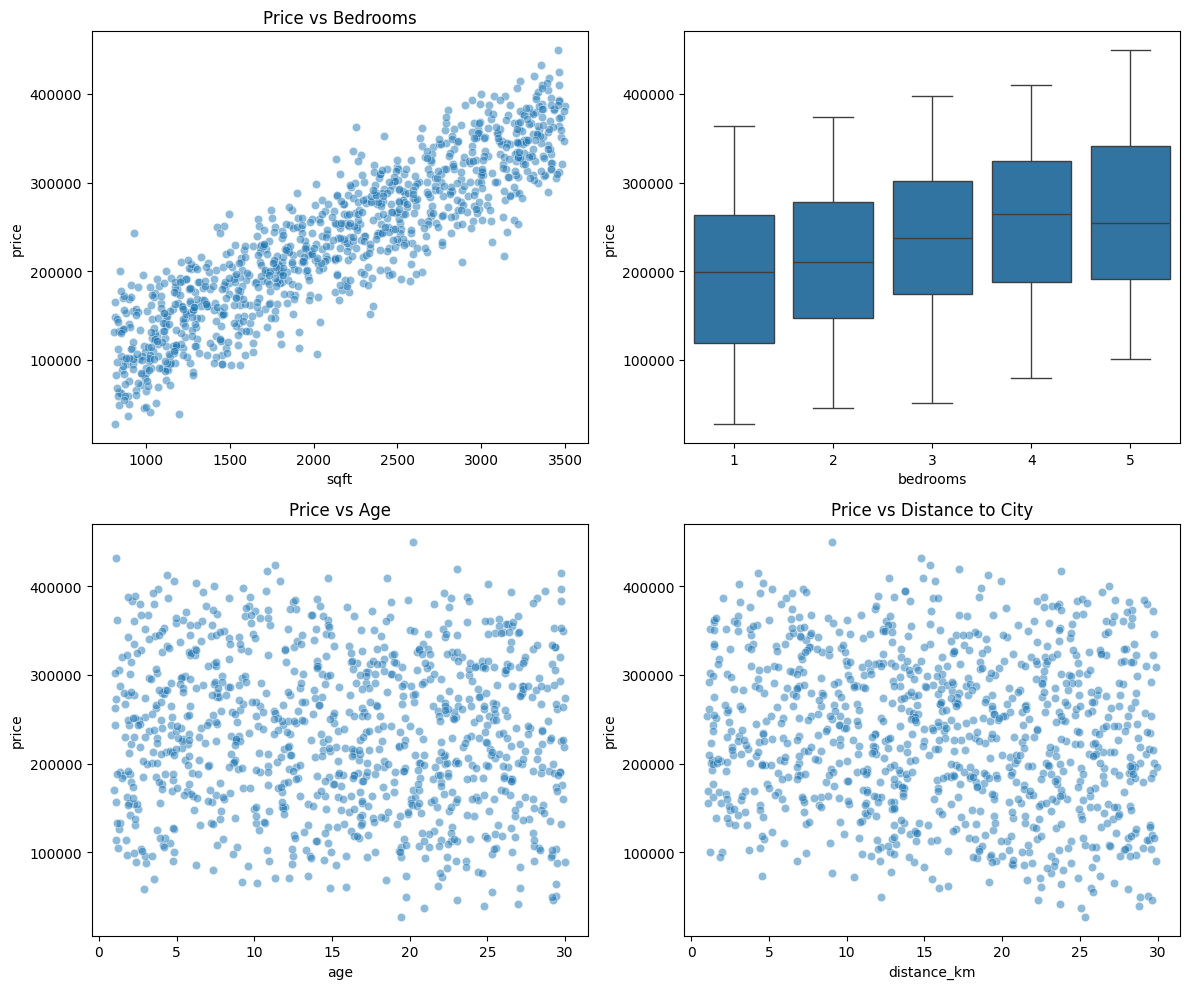


Correlations with price:
price          1.000000
sqft           0.896212
bedrooms       0.301714
age           -0.065602
distance_km   -0.122028
Name: price, dtype: float64


In [26]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

sns.scatterplot(data=df, x='sqft', y='price', ax=axes[0,0], alpha=0.5)
axes [0,0].set_title('Price vs Square Feet')

sns.boxplot(data=df, x='bedrooms', y='price', ax=axes[0,1])
axes [0,0].set_title('Price vs Bedrooms')

sns.scatterplot(data=df, x='age', y='price', ax=axes[1,0], alpha=0.5)
axes[1,0].set_title('Price vs Age')

sns.scatterplot(data=df, x='distance_km', y='price', ax=axes[1,1], alpha=0.5)
axes[1,1].set_title('Price vs Distance to City')

plt.tight_layout()
plt.show()

print("\nCorrelations with price:")
print(df.corr()['price'].sort_values(ascending=False))



In [28]:
#prepare Data
X=df[['sqft','bedrooms','age','distance_km']].values
y=df['price'].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Convert to tensors
X_train_t = torch.FloatTensor(X_train_scaled).to(device)
y_train_t = torch.FloatTensor(y_train_scaled).to(device)
X_test_t = torch.FloatTensor(X_test_scaled).to(device)
y_test_t = torch.FloatTensor(y_test_scaled).to(device)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")


Training samples: 800
Test samples: 200


In [30]:
class LinearRegression(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        # Single linear layer: y = Wx + b
        self.linear = nn.Linear(input_size, 1)
    
    def forward(self, x):
        return self.linear(x)

model = LinearRegression(input_size=4).to(device)
print(model)

# Loss function: Mean Squared Error
criterion = nn.MSELoss()

# Optimizer: adjust weights to minimize loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

LinearRegression(
  (linear): Linear(in_features=4, out_features=1, bias=True)
)


In [ ]:
epochs = 200
losses = []

for epoch in range(epochs):
    # Forward pass
    predictions = model(X_train_t)
    loss = criterion(predictions, y_train_t)
    
    # Backward pass
    optimizer.zero_grad()  # Clear old gradients
    loss.backward()        # Calculate new gradients
    optimizer.step()       # Update weights
    
    losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Progress')
plt.grid(True)
plt.show()

Mean Absolute Error: $62,259
R² Score: 0.2080

Interpretation: Model predictions are off by ~$62,259 on average


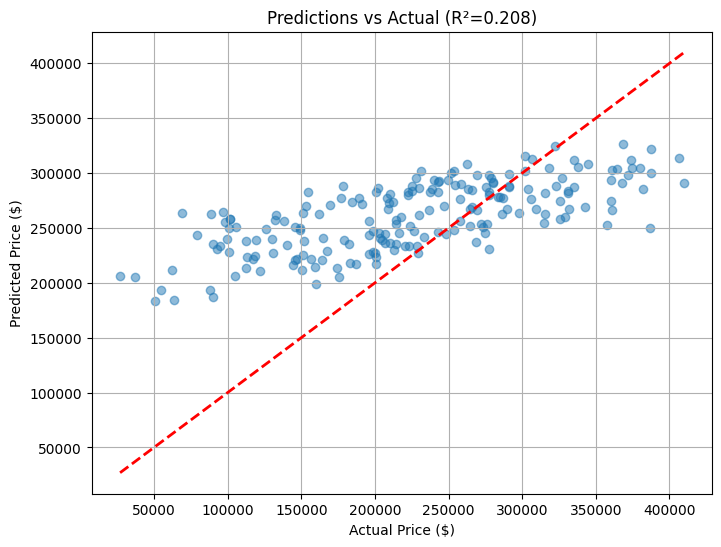

In [32]:
model.eval()
with torch.no_grad():
    # Predictions on test set
    y_pred_scaled = model(X_test_t).cpu().numpy()
    
    # Denormalize to original price scale
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    
# Calculate metrics
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:,.0f}")
print(f"R² Score: {r2:.4f}")
print(f"\nInterpretation: Model predictions are off by ~${mae:,.0f} on average")

# Visualize predictions vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Predictions vs Actual (R²={r2:.3f})')
plt.grid(True)
plt.show()


In [33]:
weights = model.linear.weight.data.cpu().numpy()[0]
bias = model.linear.bias.data.cpu().numpy()[0]

feature_names = ['sqft', 'bedrooms', 'age', 'distance_km']

# Denormalize weights to interpret in original scale
actual_weights = weights / scaler_X.scale_ * scaler_y.scale_

print("Learned coefficients (impact on price):")
for name, w in zip(feature_names, actual_weights):
    print(f"{name:15s}: ${w:,.2f}")
print(f"\nBase price: ${scaler_y.inverse_transform([[bias]])[0][0]:,.0f}")

# Compare to true formula
print("\n--- True Formula (what we used to generate data) ---")
print("sqft:           $100.00")
print("bedrooms:       $20,000.00")
print("age:            -$500.00")
print("distance_km:    -$2,000.00")

Learned coefficients (impact on price):
sqft           : $25.12
bedrooms       : $255.05
age            : $-2,460.30
distance_km    : $-1,182.93

Base price: $260,322

--- True Formula (what we used to generate data) ---
sqft:           $100.00
bedrooms:       $20,000.00
age:            -$500.00
distance_km:    -$2,000.00


In [34]:
def predict_price(sqft, bedrooms, age, distance_km):
    """Predict price for a house"""
    # Create input
    house = np.array([[sqft, bedrooms, age, distance_km]])
    
    # Normalize
    house_scaled = scaler_X.transform(house)
    house_tensor = torch.FloatTensor(house_scaled).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        pred_scaled = model(house_tensor).cpu().numpy()
        pred_price = scaler_y.inverse_transform(pred_scaled)[0][0]
    
    return pred_price

# Test predictions
test_houses = [
    (2000, 3, 10, 5),    # 2000 sqft, 3 bed, 10 years old, 5km away
    (1500, 2, 20, 15),   # Smaller, older, farther
    (3000, 4, 5, 3),     # Larger, newer, closer
]

print("House Price Predictions:")
print("-" * 60)
for sqft, beds, age, dist in test_houses:
    price = predict_price(sqft, beds, age, dist)
    print(f"{sqft} sqft, {beds} bed, {age}yr old, {dist}km → ${price:,.0f}")

House Price Predictions:
------------------------------------------------------------
2000 sqft, 3 bed, 10yr old, 5km → $284,001
1500 sqft, 2 bed, 20yr old, 15km → $234,754
3000 sqft, 4 bed, 5yr old, 3km → $324,043
